# Rb-Sr geochronology processing

This code was used for matrix-matched calibration of the Rb-Sr data, age calculations, uncertainty propagation, and validation.

In [1]:
library(IsoplotR)
library(readr)
library(dplyr,warn.conflicts = FALSE)
library(tidyr)

## Helper Functions

In [2]:
# the column names which IsoplotR needs
Rb_Sr_cols_uncalibr <- c(
  "StdCorr_Rb87_Sr86s_mean",
  "StdCorr_Rb87_Sr86s_2SE(int)",
  "StdCorr_Sr87s_Sr86s_mean",
  "StdCorr_Sr87s_Sr86s_2SE(int)",
  "87Rb/86Sr - 87Sr/86Sr Rho"
)
Rb_Sr_cols_calibrated <- Rb_Sr_cols_uncalibr
Rb_Sr_cols_calibrated[1] <- "StdCorr_Rb87_Sr86s_mean_calibr"

filter_data <- function(df, spot_id_prefix) {
  df %>% filter(startsWith(spot_id, spot_id_prefix))
}

fit_anchored_isochron <- function(df, sr0, inverse = FALSE, colour = "#4e79a7") {

  data <- IsoplotR::read.data(df, method = "Rb-Sr", format = 1, ierr = 2)

  IsoplotR::settings("iratio", "Sr87Sr86", sr0$value, sr0$err_2se)

  IsoplotR::isochron(
    data,
    inverse = inverse, title = FALSE,
    oerr = 2, exterr = FALSE,
    ellipse.fill = paste(colour, "80", sep = ""),
    ellipse.stroke = NA,
    tck = 0.02, las = 1, xaxs = "i", yaxs = "i",
    anchor = 1
  )
}

get_fit_errs <- function(fit_vect, variable = "age") {
  # age maps to t, initial Sr ratio maps to y in IsoplotR fit objects
  key <- switch(
    variable,
    age = "t",
    Sr0 = "y",
  )

  fit_val <- fit_vect[[key]]

  # use disp[...] when overdispersed; otherwise use s[...]
  disp_key <- paste0("disp[", key, "]")
  s_key <- paste0("s[", key, "]")

  if (disp_key %in% names(fit_vect) && !is.null(fit_vect[[disp_key]]) && !is.na(fit_vect[[disp_key]])) {
    fit_err <- fit_vect[[disp_key]]
  } else if (s_key %in% names(fit_vect) && !is.null(fit_vect[[s_key]]) && !is.na(fit_vect[[s_key]])) {
    fit_err <- fit_vect[[s_key]]
  }

  return(list(value = as.numeric(fit_val), err_2se = as.numeric(fit_err) * 2))
}

calculate_correction_factor <- function(measured_age, ref_age) {
  measured_age / ref_age
}

apply_correction_factor <- function(df, corr_factor) {
  df <- df %>% mutate(
    StdCorr_Rb87_Sr86s_mean_calibr = StdCorr_Rb87_Sr86s_mean * corr_factor
  )
  df <- df %>%
    select(spot_id, all_of(Rb_Sr_cols_calibrated), StdCorr_Rb87_Sr86s_mean, everything())
}

pretty_print_Sr0 <- function(sr0) {
  sprintf("%.4f ± %.4f", sr0$value, sr0$err_2se)
}

ppm2mol <- function(ppm, element) {
  # convert ppm to mol/kg, given an element

  molar_masses <- c(
    Na = 22.98976928,
    K = 39.0983,
    Ca = 40.078
  )

  # ppm == mg/kg. Convert to g/kg
  g_kg <- ppm / 1000

  # convert g/kg to mol/kg by dividing by the molar mass of the element
  mol_kg <- g_kg / molar_masses[element]

  return(mol_kg)
}

## Load data and constants

Load the data exported from iolite:

In [3]:
s2_df <- read_csv("data/RbSr_session2_90um.csv", comment = "##", show_col_types = FALSE) %>%
  mutate(session = 2, spot_size = 90)

In [4]:
s3_df <- read_csv("data/RbSr_session3_70um.csv", comment = "##", show_col_types = FALSE) %>%
  mutate(session = 3, spot_size = 70)

The uncertainties on these values are common to all measurement sessions.
The error on the Rb/Sr reference value cancels during the matrix correction.

In [5]:
# NIST610 (primary RM) values from Rösel & Zack (2022)
NIST610_RbSr_REF_VAL <- list(value = 2.33, err_2se = 0.0049)
NIST610_SrSr_REF_VAL <- list(value = 0.709699, err_2se = 0.000018)

# MCRM (matrix correction RM) long term variance (estimate after Rosel & Zack, 2022)
MCRM_LONG_TERM_VAR <- 0.02 # 2%

# decay constant for 87Rb (Villa et al., 2015)
LAMBDA_Rb <- list(value = 1.3972e-11, err_2se = 0.0045e-11)

## Recalculations

### Recalculate E44794 Haytor West (Darbyshire & Shepherd, 1985)

Reference age is from Darbyshire & Shepherd (1985). Recalculate their sample E44794 isochron with modern decay constant, using the data in their Table 5.

In [6]:
d_and_s_df <- read_csv("data/Darbyshire_Shepherd_Tbl_5.csv", show_col_types = FALSE)

> "Analytical uncertainties are estimated at 0.02% for <sup>87</sup>Sr/<sup>86</sup>Sr and 1.0% for <sup>87</sup>Rb/<sup>86</sup>Sr."\
> (Darbyshire and Shepherd, 1985, p. 1161)

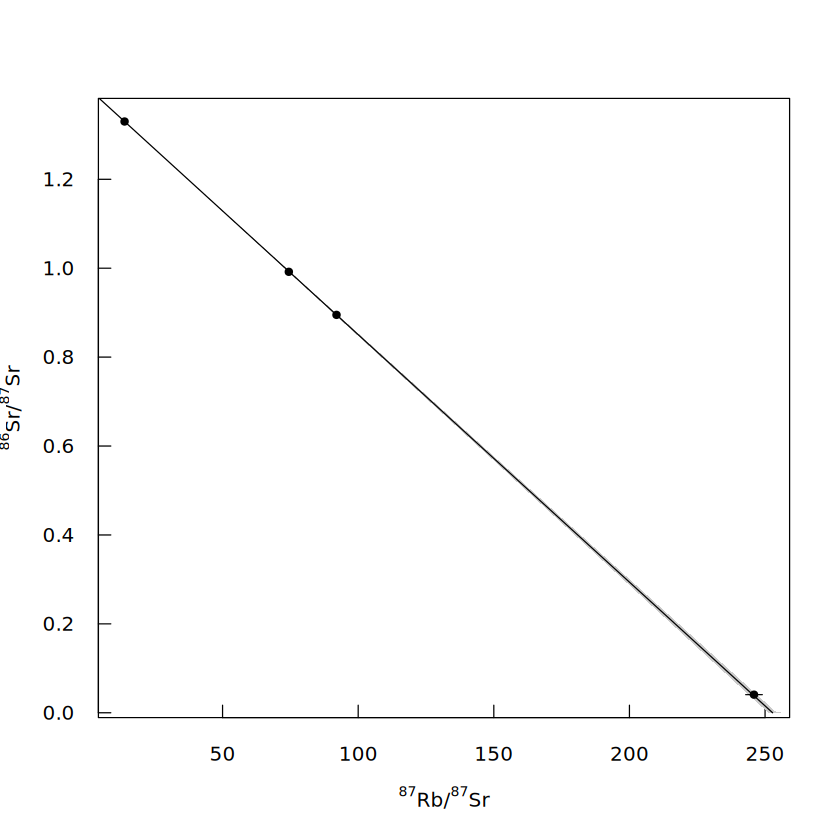

In [7]:
d_and_s_df <- d_and_s_df %>%
  mutate(Sr87s_Sr86_err = 0.02, Rb87_Sr86_err = 1) %>%
  select(Rb87_Sr86, Rb87_Sr86_err, Sr87s_Sr86, Sr87s_Sr86_err)

ds_obj <- IsoplotR::read.data(d_and_s_df, method = "Rb-Sr", format = 1, ierr = 4)


ds_fit <- IsoplotR::isochron(
  ds_obj,
  oerr = 2, exterr = TRUE, inverse = TRUE, title = FALSE,
  ellipse.fill = "#E44794",
  tck = 0.02, las = 1, xaxs = "r", yaxs = "r", cex = 0.8
)

HG1_ds_age <- get_fit_errs(ds_fit$age)
HG1_ds_Sr0 <- get_fit_errs(ds_fit$y0, variable = "Sr0")

In [8]:
noquote("E44794 (Haytor West Quarry)")
noquote(paste("Recalculated age ± 2SE:", round(HG1_ds_age$value, 0), "±", round(HG1_ds_age$err_2se, 0), "Ma"))
noquote(paste("87Sr/86Srᵢ:", pretty_print_Sr0(HG1_ds_Sr0)))
noquote(paste("MSWD:", round(ds_fit$mswd, 2)))
noquote(paste("p(χ²):", round(ds_fit$p.value, 2)))


[1] E44794 (Haytor West Quarry)

[1] Recalculated age ± 2SE: 283 ± 3 Ma

[1] 87Sr/86Srᵢ: 0.7107 ± 0.0005

[1] MSWD: 0.18

[1] p(χ²): 0.84

### Recalculate Mountsorrel granodiorite (Cribb, 1975)

Data from Cribb (1975) Table 1. Errors are quoted at the 2s level.

In [9]:
cribb_df <- read_csv("data/Cribb_Tbl_1.csv", show_col_types = FALSE)

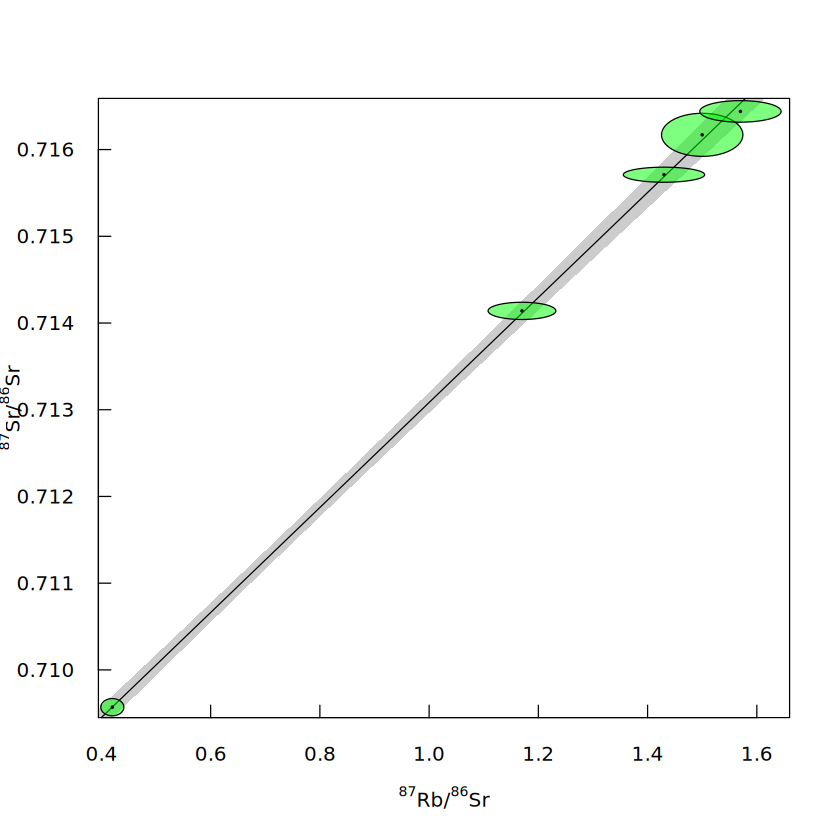

In [10]:
cribb_df <- cribb_df %>%
  select(Rb87_Sr86, Rb87_Sr86_err2s, Sr87s_Sr86, Sr87s_Sr86_err2s)

cribb_obj <- IsoplotR::read.data(cribb_df, method = "Rb-Sr", format = 1, ierr = 2)

cribb_fit <- IsoplotR::isochron(
  cribb_obj,
  oerr = 2, exterr = TRUE, title = FALSE,
  tck = 0.02, las = 1, xaxs = "i", yaxs = "i"
)
cribb_r_age <- get_fit_errs(cribb_fit$age)
cribb_r_sr0 <- get_fit_errs(cribb_fit$y0, variable = "Sr0")

In [11]:
noquote("Recalculated Mountsorrel granodiorite")
noquote(paste("age:", round(cribb_r_age$value, 0), "±", round(cribb_r_age$err_2se, 0), "Ma"))
noquote(paste("87Sr/86Srᵢ:", pretty_print_Sr0(cribb_r_sr0)))
noquote(paste("MSWD:", round(cribb_fit$mswd, 2)))
noquote(paste("p(χ²):", round(cribb_fit$p.value, 2)))

[1] Recalculated Mountsorrel granodiorite

[1] age: 432 ± 16 Ma

[1] 87Sr/86Srᵢ: 0.7070 ± 0.0002

[1] MSWD: 0.13

[1] p(χ²): 0.94

### Recalculate BB1 (Gibson et al., 1987)

BB-1 is from Mourne granite "G2" of Gibson et al. (1987). They report a whole-rock age of 55.9 ± 0.4 Ma (2s) (their Table 1) using a decay constant of 1.42e-11 yr⁻¹.

Adjust the age to the modern decay constant of 1.3972e-11 yr⁻¹ (Villa et al., 2015):

In [12]:
bb1_ref_age_old <- 55.9
bb1_recalc_corr_factor <- 1.42e-11 / LAMBDA_Rb$value
bb1_ref_age_new <- bb1_ref_age_old * bb1_recalc_corr_factor
bb1_ref_age_err_new <- 0.4 * (1.42e-11 / LAMBDA_Rb$value)

In [13]:
noquote(paste("BB1 recalculated age ± 2SE:", round(bb1_ref_age_new, 2), "±", round(bb1_ref_age_err_new, 2), "Ma"))
noquote(paste("Correction factor:", round(bb1_recalc_corr_factor, 3)))

[1] BB1 recalculated age ± 2SE: 56.81 ± 0.41 Ma

[1] Correction factor: 1.016

## Reference ages

In [14]:
# Cribb (1975) recalculation
MSG_REF_AGE <- cribb_r_age
MSG_REF_Sr0 <- cribb_r_sr0

# Gibson et al. (1987) Table 1 (recalculated)
BB1_REF_AGE <- list(value = bb1_ref_age_new, err_2se = bb1_ref_age_err_new)
BB1_REF_Sr0 <- list(value = 0.7109, err_2se = 0.0003)

# Darbyshire & Shepherd (1985) recalculation
HG1_REF_AGE <- HG1_ds_age
HG1_REF_Sr0 <- HG1_ds_Sr0

## External error propagation functions

In [15]:
get_session_ext_2rs_sq <- function(mcrm_meas_age_obj, mcrm_ref_age) {
  mcrm_meas_age <- get_fit_errs(mcrm_meas_age_obj$age)
  return(
    (mcrm_meas_age[["err_2se"]] / mcrm_meas_age[["value"]])^2
    + (mcrm_ref_age$err_2se / mcrm_ref_age$value)^2
  )
}

get_common_syst_errs_sum_of_sq <- function() {
  return(
    (NIST610_SrSr_REF_VAL$err_2se / NIST610_SrSr_REF_VAL$value)^2
    + MCRM_LONG_TERM_VAR^2
    + (LAMBDA_Rb$err_2se / LAMBDA_Rb$value)^2
  )
}

append_ext_2rs <- function(df, mcrm_meas_age_obj, mcrm_ref_age, session) {
  df <- df %>% mutate(
    ext_sys_errs_2rs_partial_sum_sq = get_session_ext_2rs_sq(mcrm_meas_age_obj, mcrm_ref_age)
    + get_common_syst_errs_sum_of_sq()
  )
}

prop_ext_errs <- function(value, internal_2s, ext_errs_partial_sum) {
  return(value * sqrt((internal_2s / value)^2 + ext_errs_partial_sum))
}

## Session 240507 (S2)

### S2 NIST-calibrated age, Haytor granite

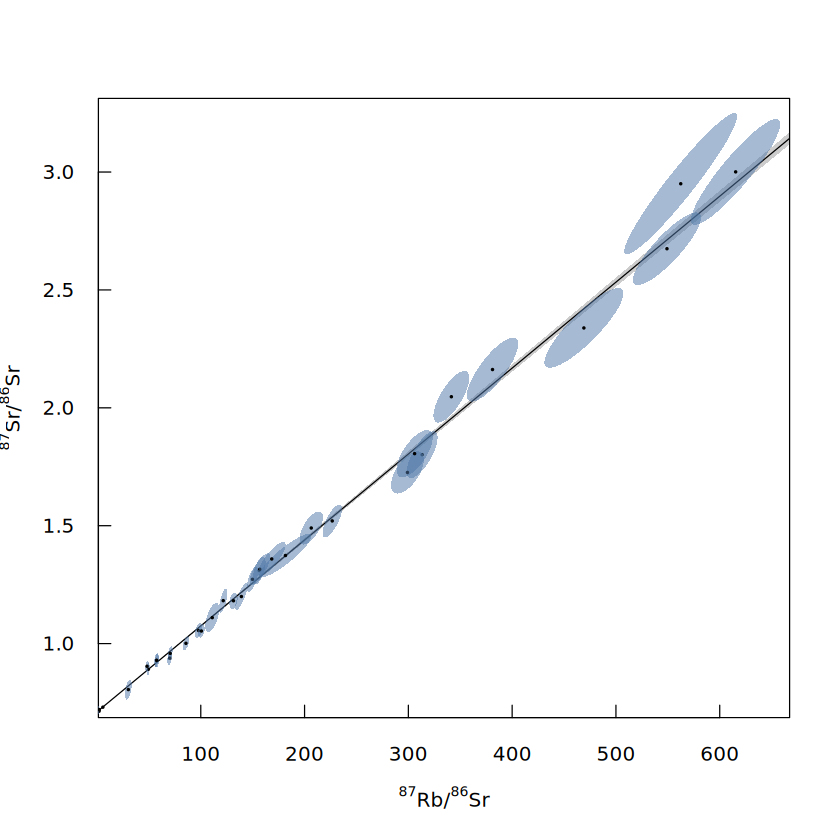

In [16]:
s2_hg1_kfs_df <- filter_data(s2_df, "DG2-Fsp") # DG2 was a working name before renaming to HG1
s2_hg1_fit <- fit_anchored_isochron(s2_hg1_kfs_df[Rb_Sr_cols_uncalibr], sr0 = HG1_REF_Sr0)
s2_hg1_age <- get_fit_errs(s2_hg1_fit$age)
s2_hg1_sr0 <- get_fit_errs(s2_hg1_fit$y0, variable = "Sr0")

In [17]:
noquote("Session 240507 HG-1 (feldspar only)")
noquote(paste0("age (NIST-calibrated) ± 2SE (internal) (2rs): ", round(s2_hg1_age$value, 0), " ± ", round(s2_hg1_age$err_2se, 0), " Ma (", round(s2_hg1_age$err_2se / s2_hg1_age$value * 100, 1), "%)"))
noquote(paste0("87Sr/86Srᵢ: ", pretty_print_Sr0(s2_hg1_sr0), " (anchored to ", pretty_print_Sr0(HG1_REF_Sr0), ")"))
noquote(paste("MSWD:", round(s2_hg1_fit$mswd, 2)))
noquote(paste("p(χ²):", round(s2_hg1_fit$p.value, 2)))
noquote(paste("n (used/total):", s2_hg1_fit$n[1], "/", nrow(s2_hg1_kfs_df)))

[1] Session 240507 HG-1 (feldspar only)

[1] age (NIST-calibrated) ± 2SE (internal) (2rs): 260 ± 4 Ma (1.7%)

[1] 87Sr/86Srᵢ: 0.7106 ± 0.0017 (anchored to 0.7107 ± 0.0005)

[1] MSWD: 2.55

[1] p(χ²): 0

[1] n (used/total): 34 / 34

### S2 correction factor

Calculate the correction factor to apply to K-feldspar unknowns:

In [18]:
noquote(paste("Using reference age:", round(HG1_REF_AGE$value, 0), "±", round(HG1_REF_AGE$err_2se, 0), "Ma"))

s2_corr_factor <- calculate_correction_factor(s2_hg1_age$value, HG1_REF_AGE$value)

noquote(paste("Correction factor:", round(s2_corr_factor, 3)))

[1] Using reference age: 283 ± 3 Ma

[1] Correction factor: 0.921

### S2 calibration of unknowns

In [19]:
s2_unknowns_df <- filter_data(s2_df, spot_id_prefix = "GM")
s2_unknowns_df <- apply_correction_factor(s2_unknowns_df, s2_corr_factor)

### S2 calculate uncertainties

Check that the MSWD for the primary RM is <1 and therefore no propagation of the excess variance is needed:

In [20]:
# NIST610 (primary RM)
s2_NIST610 <- filter_data(s2_df, "NIST610")
s2_NIST610_SrSr <- IsoplotR::weightedmean(as.matrix(s2_NIST610[, c("StdCorr_Sr87s_Sr86s_mean", "StdCorr_Sr87s_Sr86s_2SE(int)")]) / 2, oerr = 2, plot = FALSE)
s2_NIST610_RbSr <- IsoplotR::weightedmean(as.matrix(s2_NIST610[, c("StdCorr_Rb87_Sr86s_mean", "StdCorr_Rb87_Sr86s_2SE(int)")]) / 2, oerr = 2, plot = FALSE)

noquote(paste("MSWD 87Sr/86Sr =", round(s2_NIST610_SrSr$mswd, 3)))
noquote(paste("MSWD 87Rb/86Sr =", round(s2_NIST610_RbSr$mswd, 3)))

[1] MSWD 87Sr/86Sr = 0.046

[1] MSWD 87Rb/86Sr = 0.072

Calculate and store uncertainties in the unknowns table to apply to the final age.

In [21]:
# add the systematic uncertainty of the measured MCRM age to the other systematic uncertainties
s2_unknowns_df <- append_ext_2rs(s2_unknowns_df, s2_hg1_fit, HG1_REF_AGE, session = 2)

## Session 251017 (S3)

### S3 NIST-calibrated age, Haytor granite

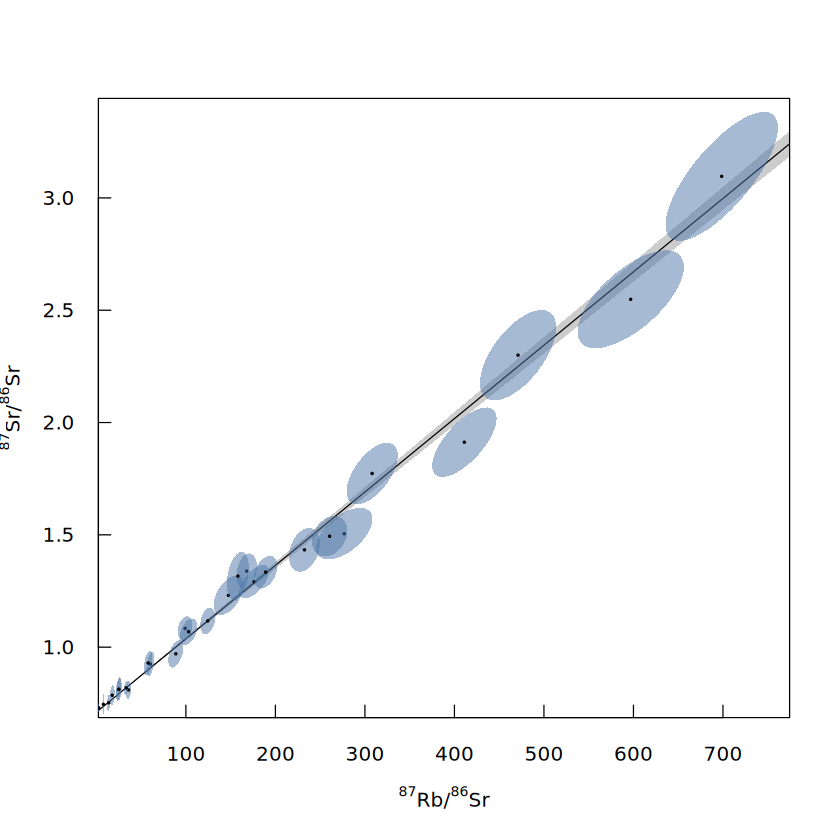

In [22]:
s3_hg1_kfs_df <- filter_data(s3_df, "DG2_fsp") # DG2 was a working name before renaming to HG1
s3_hg1_fit <- fit_anchored_isochron(s3_hg1_kfs_df[Rb_Sr_cols_uncalibr], sr0 = HG1_REF_Sr0)
s3_hg1_age <- get_fit_errs(s3_hg1_fit$age)
s3_hg1_sr0 <- get_fit_errs(s3_hg1_fit$y0, variable = "Sr0")

In [23]:
noquote("Session 251017 HG-1 (feldspar only)")
noquote(paste0("age (NIST-calibrated) ± 2SE (internal) (2rs): ", round(s3_hg1_age$value, 0), " ± ", round(s3_hg1_age$err_2se, 0), " Ma (", round(s3_hg1_age$err_2se / s3_hg1_age$value * 100, 1), "%)"))
noquote(paste0("87Sr/86Srᵢ: ", pretty_print_Sr0(s3_hg1_sr0), " (anchored to ", pretty_print_Sr0(HG1_REF_Sr0), ")"))
noquote(paste("MSWD:", round(s3_hg1_fit$mswd, 2)))
noquote(paste("p(χ²):", round(s3_hg1_fit$p.value, 4)))
noquote(paste("n (used/total):", s3_hg1_fit$n[1], "/", nrow(s3_hg1_kfs_df)))

[1] Session 251017 HG-1 (feldspar only)

[1] age (NIST-calibrated) ± 2SE (internal) (2rs): 233 ± 8 Ma (3.2%)

[1] 87Sr/86Srᵢ: 0.7108 ± 0.0016 (anchored to 0.7107 ± 0.0005)

[1] MSWD: 2.09

[1] p(χ²): 7e-04

[1] n (used/total): 27 / 27

### S3 correction factor

Calculate the correction factor to apply to K-feldspar unknowns:

In [24]:
noquote(paste("Using reference age:", round(HG1_REF_AGE$value, 0), "±", round(HG1_REF_AGE$err_2se, 0), "Ma"))

s3_corr_factor <- calculate_correction_factor(s3_hg1_age$value, HG1_REF_AGE$value)

noquote(paste("Correction factor:", round(s3_corr_factor, 3)))

[1] Using reference age: 283 ± 3 Ma

[1] Correction factor: 0.826

### S3 calibration of unknowns

In [25]:
s3_unknowns_df <- filter_data(s3_df, spot_id_prefix = "GM")
s3_unknowns_df <- apply_correction_factor(s3_unknowns_df, s3_corr_factor)

### S3 calculate uncertainties

Check that the MSWD for the primary RM is <1 and therefore no propagation of the excess variance is needed:

In [26]:
# NIST610 (primary RM)
s3_NIST610 <- filter_data(s3_df, "NIST610")
s3_NIST610_SrSr <- IsoplotR::weightedmean(as.matrix(s3_NIST610[, c("StdCorr_Sr87s_Sr86s_mean", "StdCorr_Sr87s_Sr86s_2SE(int)")]) / 2, oerr = 2, plot = FALSE)
s3_NIST610_RbSr <- IsoplotR::weightedmean(as.matrix(s3_NIST610[, c("StdCorr_Rb87_Sr86s_mean", "StdCorr_Rb87_Sr86s_2SE(int)")]) / 2, oerr = 2, plot = FALSE)

noquote(paste("MSWD 87Sr/86Sr =", round(s3_NIST610_SrSr$mswd, 3)))
noquote(paste("MSWD 87Rb/86Sr =", round(s3_NIST610_RbSr$mswd, 3)))

[1] MSWD 87Sr/86Sr = 0.184

[1] MSWD 87Rb/86Sr = 0.078

Calculate and store uncertainties in the unknowns table to apply to the final age.

In [27]:
# add the systematic uncertainty of the measured MCRM age to the other systematic uncertainties
s3_unknowns_df <- append_ext_2rs(s3_unknowns_df, s3_hg1_fit, HG1_REF_AGE, session = 2)

In [28]:
rb_sr_df <- bind_rows(s2_unknowns_df, s3_unknowns_df)

## Initial <sup>87</sup>Sr/<sup>86</sup>Sr ratio

Use the larger spots (150 or 160 µm) in plagioclase grains.

In [29]:
plag_s2 <- read_csv("data/RbSr_session2_150um.csv", comment = "##", show_col_types = FALSE) %>%
  mutate(session = 2, spot_size = 150) %>%
  mutate(
    # convert feldspar major element ppm to mol/kg
    K_mol_kg = ppm2mol(K39_ppm_mean, "K"),
    Na_mol_kg = ppm2mol(Na23_ppm_mean, "Na"),
    Ca_mol_kg = ppm2mol(Ca43_ppm_mean, "Ca")
  )

In [30]:
plag_s3 <- read_csv("data/RbSr_session3_160um.csv", comment = "##", show_col_types = FALSE) %>%
  mutate(session = 3, spot_size = 160) %>%
  mutate(
    # convert feldspar major element ppm to mol/kg
    K_mol_kg = ppm2mol(K39_ppm_mean, "K"),
    Na_mol_kg = ppm2mol(Na23_ppm_mean, "Na"),
    Ca_mol_kg = ppm2mol(Ca43_ppm_mean, "Ca")
  )

In [31]:
plag <- bind_rows(plag_s2, plag_s3)

# calculate 1SE from 2SE for IsoplotR weighted mean
# (!!sym is needed to use column names with special characters)
plag <- mutate(plag, Sr87s_Sr86s_1SE_int = !!sym("StdCorr_Sr87s_Sr86s_2SE(int)") / 2)
plag <- plag %>% filter(startsWith(spot_id, "GM")) # exclude RMs

Screen for suspicious major element compositions:

- <sup>87</sup>Rb/<sup>86</sup>Sr > 0.3, or
- K molar abundance > 10%

Then calculate a weighted mean <sup>87</sup>Sr/<sup>86</sup>Sr ratio:

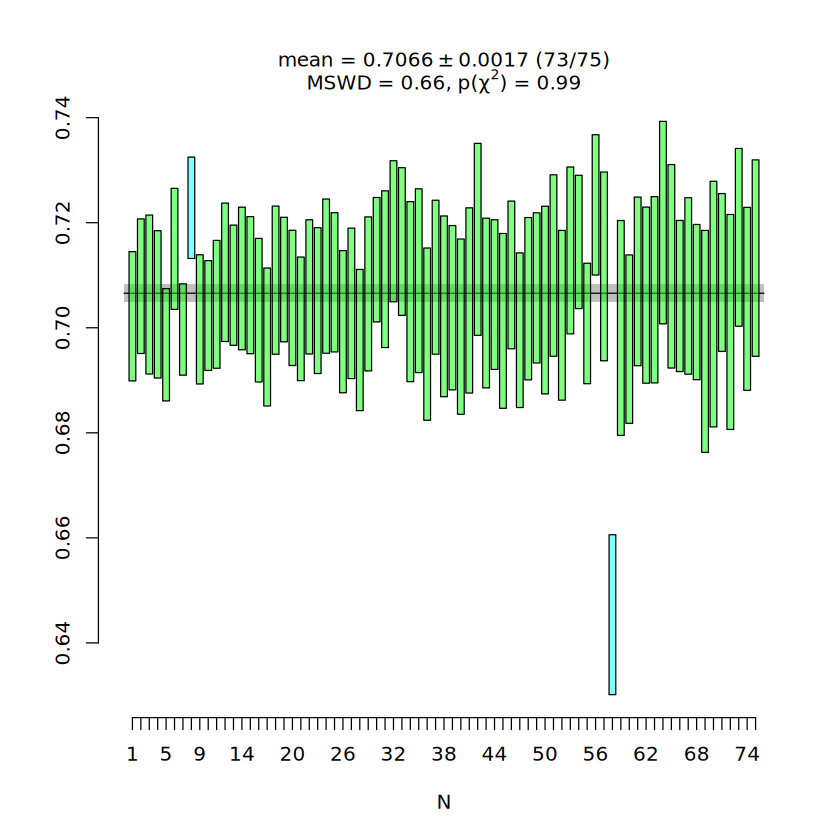

In [32]:
plag_screened <- plag %>% filter(StdCorr_Rb87_Sr86s_mean < 0.3)
plag_screened <- plag_screened %>% filter(K_mol_kg / (K_mol_kg + Na_mol_kg + Ca_mol_kg) < 0.1)

wmean <- IsoplotR::weightedmean(
  x = as.matrix(plag_screened[, c("StdCorr_Sr87s_Sr86s_mean", "Sr87s_Sr86s_1SE_int")]),
  oerr = 2
)
wmean_sr_sr0 <- list(val = wmean$mean[["t"]], err_2se = wmean$mean[["s[t]"]] * 2)

In [33]:
noquote(paste("Regional initial 87Sr/86Sr ratio from", sum(wmean$valid), "plagioclase grains:", round(wmean_sr_sr0$val, 5), "±", round(wmean_sr_sr0$err_2se, 5)))
noquote(paste(nrow(plag), "measured, filtered to", nrow(plag_screened), "with 87Rb/86Sr < 0.3,", sum(!wmean$valid), "outlier(s) rejected from the weighted mean."))

[1] Regional initial 87Sr/86Sr ratio from 73 plagioclase grains: 0.70658 ± 0.00168

[1] 138 measured, filtered to 75 with 87Rb/86Sr < 0.3, 2 outlier(s) rejected from the weighted mean.

## Calculate detrital ages

With two-point isochrons anchored to the initial <sup>87</sup>Sr/<sup>86</sup>Sr ratio calculated above.

In [34]:
IsoplotR::settings("iratio", "Sr87Sr86", wmean_sr_sr0$val, wmean_sr_sr0$err_2se)

age_results <- IsoplotR::age(
  IsoplotR::read.data(rb_sr_df[Rb_Sr_cols_calibrated], method = "Rb-Sr", format = 1, ierr = 2),
  isochron = FALSE, exterr = FALSE, i2i = FALSE, projerr = FALSE, oerr = 2
)

age_results <- rename(as_tibble(age_results), age = "t", age_2s_int = "err[t]")

age_results <- age_results %>%
  mutate(
    age_2s_ext = prop_ext_errs(age, age_2s_int, rb_sr_df$ext_sys_errs_2rs_partial_sum_sq),
  )

rb_sr_df <- bind_cols(rb_sr_df, age_results)

## Validation

### MSG (this study, session 2)

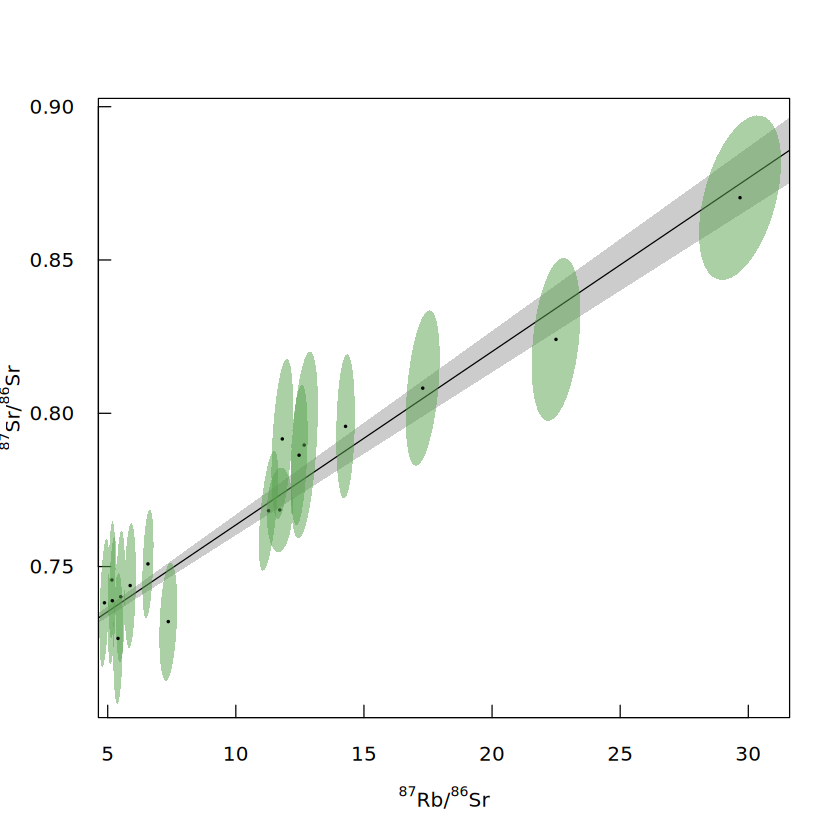

In [35]:
msg_s2_df <- filter_data(s2_df, "MSG-Kfs")
msg_s2_df <- apply_correction_factor(msg_s2_df, s2_corr_factor)

msg_s2_fit <- fit_anchored_isochron(msg_s2_df[Rb_Sr_cols_calibrated], sr0 = MSG_REF_Sr0, colour = "#59A14F")

msg_s2_age <- get_fit_errs(msg_s2_fit$age)
msg_s2_sr0 <- get_fit_errs(msg_s2_fit$y0, variable = "Sr0")

msg_s2_age_2s_ext <- prop_ext_errs(
  msg_s2_age$value,
  msg_s2_age$err_2se,
  get_session_ext_2rs_sq(s2_hg1_fit, HG1_REF_AGE) + get_common_syst_errs_sum_of_sq()
)

In [36]:
noquote("MSG (Kfs only, session 2)")
noquote(paste("Reference age:", round(MSG_REF_AGE$value, 0), "±", round(MSG_REF_AGE$err_2se, 0), "Ma"))
noquote(paste("MSG measured age ± 2SE (external):", round(msg_s2_age$value, 0), "±", round(msg_s2_age_2s_ext, 0), "Ma"))
noquote(paste0("87Sr/86Srᵢ: ", pretty_print_Sr0(msg_s2_sr0), " (anchored to ", pretty_print_Sr0(MSG_REF_Sr0), ")"))
noquote(paste("MSWD:", round(msg_s2_fit$mswd, 2)))
noquote(paste("p(χ²):", round(msg_s2_fit$p.value, 2)))
noquote(paste("n (spots):", nrow(msg_s2_df)))

[1] MSG (Kfs only, session 2)

[1] Reference age: 432 ± 16 Ma

[1] MSG measured age ± 2SE (external): 404 ± 27 Ma

[1] 87Sr/86Srᵢ: 0.7070 ± 0.0004 (anchored to 0.7070 ± 0.0002)

[1] MSWD: 1.01

[1] p(χ²): 0.44

[1] n (spots): 17

### BB-1 (this study, session 3)

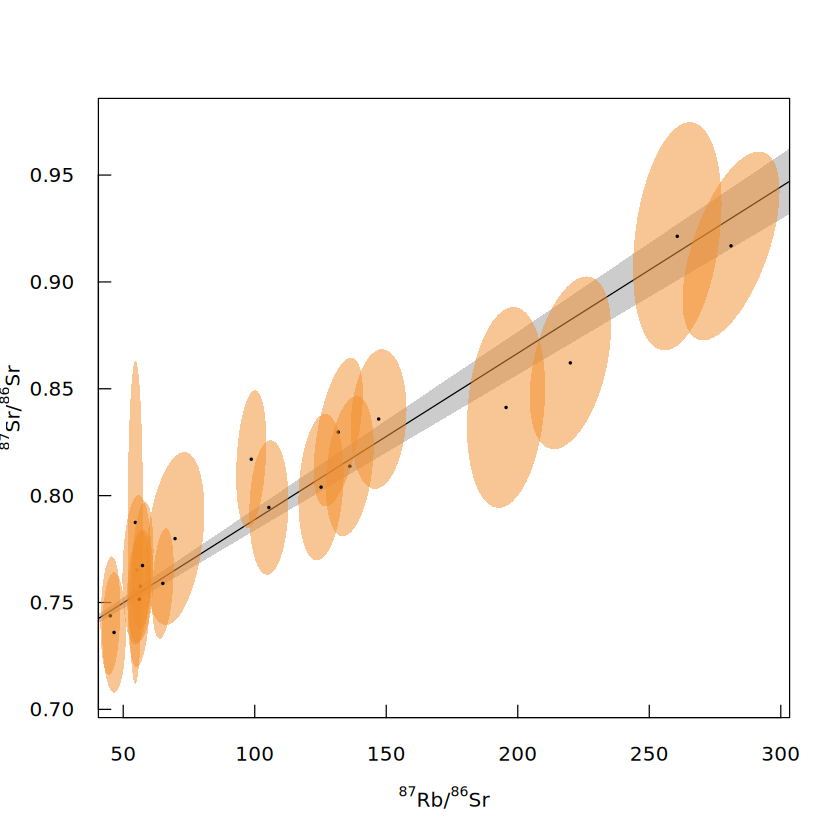

In [37]:
bb1_s3_df <- filter_data(s3_df, "BB1_")
bb1_s3_df <- apply_correction_factor(bb1_s3_df, s3_corr_factor)

bb1_s3_fit <- fit_anchored_isochron(bb1_s3_df[Rb_Sr_cols_calibrated], sr0 = BB1_REF_Sr0, colour = "#F28E2C")

bb1_s3_age <- get_fit_errs(bb1_s3_fit$age)
bb1_s3_sr0 <- get_fit_errs(bb1_s3_fit$y0, variable = "Sr0")

bb1_s3_age_2s_int <- bb1_s3_age$err_2se
bb1_s3_age_2s_ext <- prop_ext_errs(
  bb1_s3_age$value,
  bb1_s3_age$err_2se,
  get_session_ext_2rs_sq(s3_hg1_fit, HG1_REF_AGE) + get_common_syst_errs_sum_of_sq()
)

In [38]:
noquote("BB-1 (Kfs only, session 3)")
noquote(paste("Reference age:", round(BB1_REF_AGE$value, 1), "±", round(BB1_REF_AGE$err_2se, 1), "Ma"))
noquote(paste("BB-1 measured age ± 2SE (external):", round(bb1_s3_age$value, 1), "±", round(bb1_s3_age_2s_ext, 2), "Ma"))
noquote(paste0("87Sr/86Srᵢ: ", pretty_print_Sr0(bb1_s3_sr0), " (anchored to ", pretty_print_Sr0(BB1_REF_Sr0), ")"))
noquote(paste("MSWD:", round(bb1_s3_fit$mswd, 2)))
noquote(paste("p(χ²):", round(bb1_s3_fit$p.value, 2)))
noquote(paste("n (spots):", nrow(bb1_s3_df)))

[1] BB-1 (Kfs only, session 3)

[1] Reference age: 56.8 ± 0.4 Ma

[1] BB-1 measured age ± 2SE (external): 55.7 ± 4.22 Ma

[1] 87Sr/86Srᵢ: 0.7109 ± 0.0006 (anchored to 0.7109 ± 0.0003)

[1] MSWD: 0.88

[1] p(χ²): 0.6

[1] n (spots): 19

### MSG (this study, session 3)

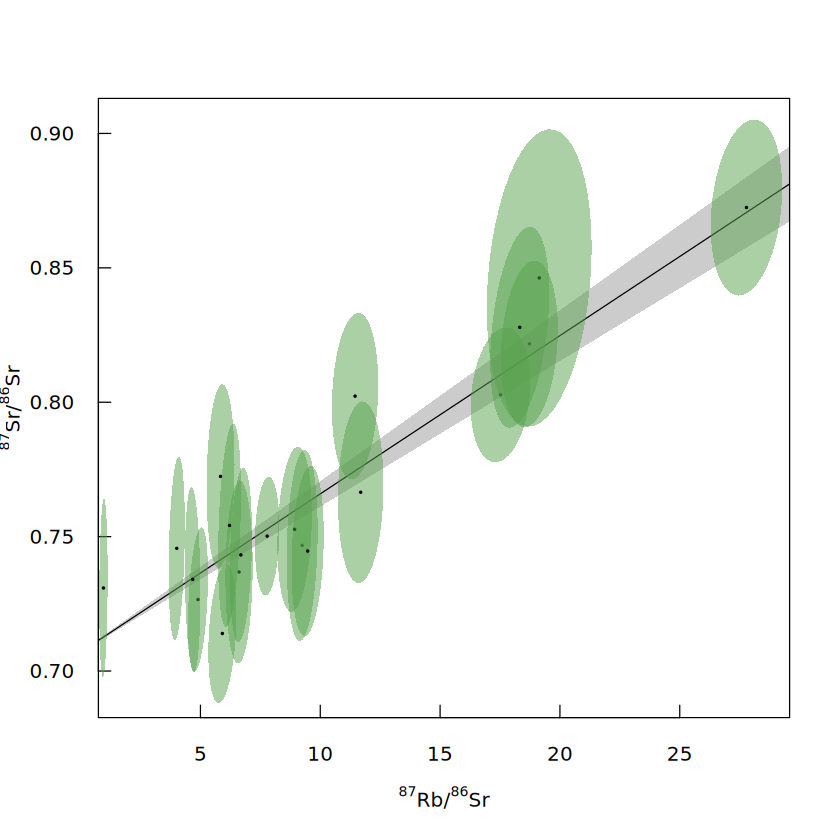

In [39]:
msg_s3_df <- filter_data(s3_df, "MSG_kfs")
msg_s3_df <- apply_correction_factor(msg_s3_df, s3_corr_factor)

msg_s3_fit <- fit_anchored_isochron(msg_s3_df[Rb_Sr_cols_calibrated], sr0 = MSG_REF_Sr0, colour = "#59A14F")

msg_s3_age <- get_fit_errs(msg_s3_fit$age)
msg_s3_sr0 <- get_fit_errs(msg_s3_fit$y0, variable = "Sr0")

msg_s3_age_2s_ext <- prop_ext_errs(
  msg_s3_age$value,
  msg_s3_age$err_2se,
  get_session_ext_2rs_sq(s3_hg1_fit, HG1_REF_AGE) + get_common_syst_errs_sum_of_sq()
)

In [40]:
noquote("MSG (Kfs only, session 3)")
noquote(paste("Reference age:", round(MSG_REF_AGE$value, 1), "±", round(MSG_REF_AGE$err_2se, 1), "Ma"))
noquote(paste("MSG measured age ± 2SE (external):", round(msg_s3_age$value, 1), "±", round(msg_s3_age_2s_ext, 2), "Ma"))
noquote(paste0("87Sr/86Srᵢ: ", pretty_print_Sr0(msg_s3_sr0), " (anchored to ", pretty_print_Sr0(MSG_REF_Sr0), ")"))
noquote(paste("MSWD:", round(msg_s3_fit$mswd, 2)))
noquote(paste("p(χ²):", round(msg_s3_fit$p.value, 2)))
noquote(paste("n (spots):", nrow(msg_s3_df)))

[1] MSG (Kfs only, session 3)

[1] Reference age: 432 ± 16.3 Ma

[1] MSG measured age ± 2SE (external): 420.2 ± 37.44 Ma

[1] 87Sr/86Srᵢ: 0.7070 ± 0.0004 (anchored to 0.7070 ± 0.0002)

[1] MSWD: 1.48

[1] p(χ²): 0.08

[1] n (spots): 20